In [1]:
import healpy as hp
import matplotlib.pyplot as plt
import numpy as np
import sys
import matplotlib.pyplot as plt

sys.path.append("/bigdata/aankit/lost_in_space/cmbml_old/utils")
from planck_cmap import colombi1_cmap

import pysm3.units as u
import pysm3 

In [2]:
dataset_dir = '/bigdata/seth/datasets_stored'
mask_dir = '/bigdata/seth/masks'
Nside = 128
freqs = [30,44,70,100,143,217,353,545,857] #Nominal detector frequencies
centers = [28.4,44.1,70.4,100.89,142.876,221.156,357.5,555.2,866.8] #Center frequencies which better approximate the true bandpasses
fwhms = [33.1, 27.94348615, 13.07645961, 9.682, 7.303, 5.021, 4.944, 4.831,4.67] #detector beam widths
centerdict = dict(zip(freqs,centers))
fwhmdict = dict(zip(freqs,centers))

mask = hp.read_map(f'{mask_dir}/Nside_{Nside}/mask.fits')
fwhm_128 = 82.5

In [3]:
def get_power(mapp1,mapp2,mask=None,maskfsky=None,lmax=None):
    #Calculate powerspectra with mask
    #mask fsky can be used to give an appropriate sky fraction without multiplying by a mask
    if mask is None:
        mask = np.ones(len(mapp1))
    mean1 = np.sum(mapp1*mask)/np.sum(mask)
    mean2 = np.sum(mapp2*mask)/np.sum(mask)

    if maskfsky is None:
        maskfsky = mask
    fsky = np.sum(maskfsky)/maskfsky.shape[0]
    return hp.anafast(mask*(mapp1-mean1),mask*(mapp2-mean2),lmax=lmax)/fsky

In [4]:
def conv_to_beam(map,fwhm_new,fwhm_orig = 0,Nside=512,lmax=None):
    #Convolves from a certain beam to a new beam. If fwhm_orig left blank will assumed inititally deconvolved
    if lmax is None:
        lmax = 3*Nside-1
        
    newbeam = hp.gauss_beam(np.radians(fwhm_new/60),lmax=lmax)
    origbeam = hp.gauss_beam(np.radians(fwhm_orig/60),lmax = lmax)
    alm = hp.map2alm(map,lmax = lmax)
    alm_c = hp.almxfl(alm, newbeam/origbeam)
    map_c = hp.alm2map(alm_c,nside=Nside)
    return map_c

In [5]:
def create_lockman_mask(radius=2.185,gal=False):
    if gal:
        lockman_mask = hp.ud_grade(hp.read_map('/bigdata/seth/masks/HFI_Mask_GalPlane-apo2_2048_R2.00.fits',field=0),128)
    else:
        npix = hp.nside2npix(Nside)
        center_ra = 161.25 #(10h 45 m)
        center_dec = 58

        theta, phi = hp.pix2ang(Nside,np.arange(npix))

        angular_distance =hp.rotator.angdist([np.radians(90-center_dec),np.radians(center_ra)],[theta,phi])
        lockman_mask = np.zeros(npix)

        lockman_mask[angular_distance < np.radians(radius)] = 1
    return lockman_mask


In [6]:
def lockman_adjust(map,lockman_mask):
    lockman_hole = map*lockman_mask
    lockman_avg = np.sum(lockman_hole)/np.sum(lockman_mask)
    lockman_map = map - lockman_avg
    return lockman_map

In [7]:
noisedict = {}
for freq in freqs:
        noise = hp.read_map(f'/bigdata/seth/ml-model/data2/Datasets/I_128_1-1/Simulation_Working/Simulation_E_Noise/Test/sim0000/noise_{freq}_map.fits')
        noisedict[freq] = noise #conv_to_beam(noise,82.5,Nside=Nside)

In [8]:
planckdict = {}
pysmdict = {}
fgs = ["d9","s1","f1","a1","cib1","ksz1","tsz1"]
for freq in freqs:
    planckdict[freq] = hp.read_map(f'/bigdata/seth/ml-model/planck_128_data/{freq}_fg_map.fits')
    pysmdict[freq] = {}
    for fg in fgs:
        pysmdict[freq][fg] = hp.read_map(f'/bigdata/seth/ml-model/pysmdata/{fg}_at_{freq}')

In [9]:
def plot_lockman_adjust(lockman_mask):
    pysm_all_component_dict = {}
    rng_piece = [200,150,100,100,150,500,3000,4e4,4e6]
    rngdict = dict(zip(freqs,rng_piece))

    before_vec =[]
    after_vec =[]
    for freq in freqs:
        print(f'Frequency: {freq} GHz')
        planck = planckdict[freq]
        
        
        sim = noisedict[freq].copy()

        for fg in fgs:
            sim += pysmdict[freq][fg]
        
        pysm_all_component_dict[freq] = sim

        diff = np.array(sim)-np.array(planck)

        before_vec.append(np.sum(diff*mask)/np.sum(planck*mask))
        print('Relative Difference Before Adjustment',np.sum(diff*mask)/np.sum(planck*mask))

        sim = lockman_adjust(sim,lockman_mask)
        planck = lockman_adjust(planck,lockman_mask)

        diff = np.array(sim)-np.array(planck)

        after_vec.append(np.sum(diff*mask)/np.sum(planck*mask))
        print('Relative Difference After Adjustment',np.sum(diff*mask)/np.sum(planck*mask))

        fig = plt.figure(figsize=(15,8))
        hp.mollview(sim*mask,min=-rngdict[freq],max=rngdict[freq],title = f'Simulation at {freq} GHz',fig=fig.number,sub=(1,3,1),cmap=colombi1_cmap)
        hp.mollview(planck*mask,min=-rngdict[freq],max=rngdict[freq],title = f'Planck at {freq} GHz',fig=fig.number,sub=(1,3,2),cmap=colombi1_cmap)
        hp.mollview(diff*mask,min=-rngdict[freq],max=rngdict[freq],title = f'Diff at {freq} GHz',fig=fig.number,sub=(1,3,3),cmap=colombi1_cmap)
        #hp.mollview(dust_estimate*lockman_mask,min=-rngdict[freq],max=rngdict[freq],title = f'Dust Est at {freq} GHz',cmap=colombi1_cmap)

        planck_avg = np.sum(planck*mask)/np.sum(mask)
        diff_avg = np.sum(diff*mask)/np.sum(mask)
    return pysm_all_component_dict, before_vec, after_vec

In [ ]:
# lockman_mask = create_lockman_mask()
# pysm_all_component_dict, before_vec, after_vec = plot_lockman_adjust(lockman_mask)

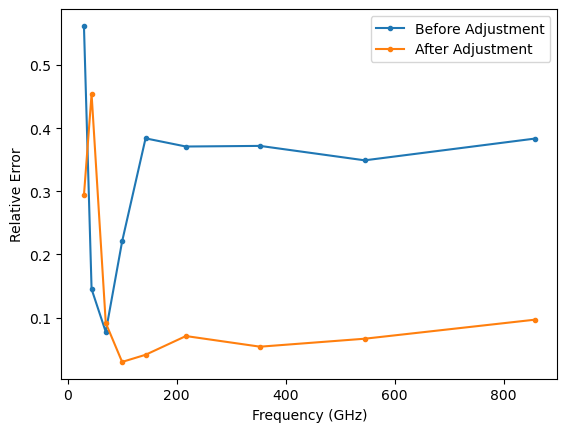

In [11]:
plt.plot(freqs,abs(np.array(before_vec)),'.-',label='Before Adjustment')
plt.plot(freqs,abs(np.array(after_vec)),'.-',label = 'After Adjustment')
plt.ylabel('Relative Error')
plt.xlabel('Frequency (GHz)')
plt.legend()

Fractional RMS difference: 1.56


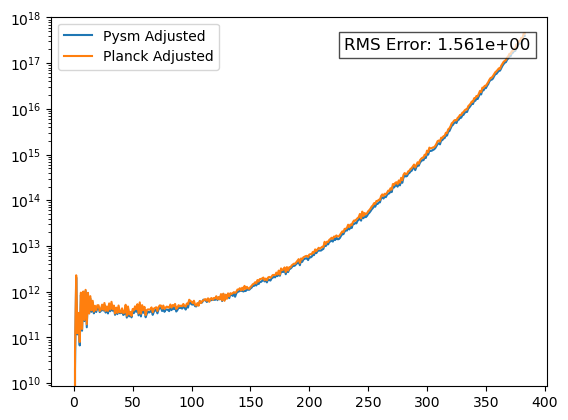

In [12]:
freq = 857
lmax = 3*Nside-1
pysm_ps = get_power(pysm_all_component_dict[freq],pysm_all_component_dict[freq],mask,lmax=lmax)
planck_ps = get_power(planckdict[freq],planckdict[freq],mask,lmax=lmax)
ells = np.arange(lmax+1)
beam = hp.sphtfunc.gauss_beam(np.radians(fwhm_128/60),lmax=lmax)
error = np.sqrt(np.mean((pysm_ps - planck_ps)**2)) / np.mean(planck_ps)
print(f"Fractional RMS difference: {error:.2f}")

# error = np.sum(pysm_ps - planck_ps) / np.sum(planck_ps)
# print("Relative difference:", error)

plt.plot(ells,ells*(ells+1)*pysm_ps/(2*np.pi*beam**2),label = 'Pysm Adjusted')
plt.plot(ells,ells*(ells+1)*planck_ps/(2*np.pi*beam**2),label = 'Planck Adjusted')
plt.text(0.6*lmax, max(ells*(ells+1)*pysm_ps/(2*np.pi*beam**2))*0.5, 
         f'RMS Error: {error:.3e}', fontsize=12, bbox=dict(facecolor='white', alpha=0.7))
plt.yscale('log')
plt.legend()

## Planck Map Matching to Simulations

In [13]:
def lockman_match(planck_map, sim_map, lockman_mask):
    planck_avg = np.sum(planck_map * lockman_mask) / np.sum(lockman_mask)
    sim_avg    = np.sum(sim_map * lockman_mask) / np.sum(lockman_mask)
    offset = sim_avg - planck_avg
    return planck_map + offset, offset

In [ ]:
def plot_lockman_match(lockman_mask):
    pysm_all_component_dict = {}
    rng_piece = [200,150,100,100,150,500,3000,4e4,4e6]
    rngdict = dict(zip(freqs,rng_piece))

    before_vec = []
    after_vec  = []
    offset_vec = []

    for freq in freqs:
        print(f'Frequency: {freq} GHz')
        planck = planckdict[freq]

        #build PySM sim = sum of all foregrounds + noise
        
        sim = noisedict[freq].copy()
        for fg in fgs:
            sim += pysmdict[freq][fg]

        pysm_all_component_dict[freq] = sim

        diff = np.array(sim) - np.array(planck)
        rel_before = np.sum(diff * mask) / np.sum(planck * mask)
        before_vec.append(rel_before)
        print('Relative Difference Before Adjustment:', rel_before)

        planck_shifted, offset = lockman_match(planck, sim, lockman_mask)
        offset_vec.append(offset)
        diff = np.array(sim) - np.array(planck_shifted)
        rel_after = np.sum(diff * mask) / np.sum(planck_shifted * mask)
        after_vec.append(rel_after)
        print('Relative Difference After Adjustment:', rel_after)

        fig = plt.figure(figsize=(15,8))
        
        hp.mollview(sim*mask, 
                    min=-rngdict[freq], max=rngdict[freq], 
                    title=f'Simulation at {freq} GHz',
                    fig=fig.number, sub=(1,4,1), cmap=colombi1_cmap)
        hp.mollview(planck*mask, 
                    min=-rngdict[freq], max=rngdict[freq], 
                    title=f'Planck at {freq} GHz',
                    fig=fig.number, sub=(1,4,2), cmap=colombi1_cmap)
        hp.mollview(planck_shifted*mask, 
                    min=-rngdict[freq], max=rngdict[freq], 
                    title=f'Planck (shifted) at {freq} GHz',
                    fig=fig.number, sub=(1,4,3), cmap=colombi1_cmap)
        hp.mollview(diff*mask, 
                    min=-rngdict[freq], max=rngdict[freq], 
                    title=f'Diff at {freq} GHz',
                    fig=fig.number, sub=(1,4,4), cmap=colombi1_cmap)

    return pysm_all_component_dict, before_vec, after_vec, offset_vec


Frequency: 30 GHz
Relative Difference Before Adjustment: 0.5619569398421708
Relative Difference After Adjustment: 0.15900731381981847
Frequency: 44 GHz
Relative Difference Before Adjustment: 0.14508194992398654
Relative Difference After Adjustment: 0.1628153322230991
Frequency: 70 GHz
Relative Difference Before Adjustment: 0.07716424769310902
Relative Difference After Adjustment: 0.015395531564175013
Frequency: 100 GHz
Relative Difference Before Adjustment: 0.2205218675378667
Relative Difference After Adjustment: 0.00927220592643578
Frequency: 143 GHz
Relative Difference Before Adjustment: 0.3838367965495451
Relative Difference After Adjustment: -0.012071356381945612
Frequency: 217 GHz
Relative Difference Before Adjustment: 0.3709059081710439
Relative Difference After Adjustment: -0.02311534748694317
Frequency: 353 GHz
Relative Difference Before Adjustment: 0.3718846042730243
Relative Difference After Adjustment: -0.019851602019104186
Frequency: 545 GHz
Relative Difference Before Adjus

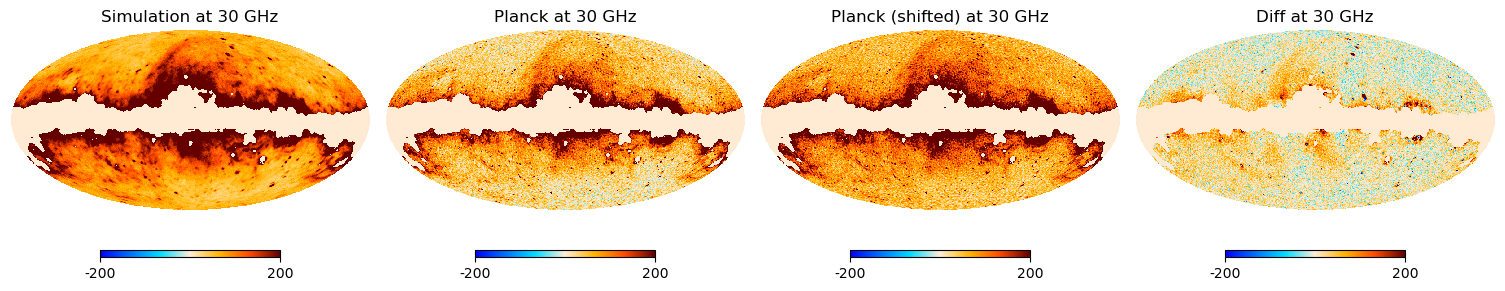

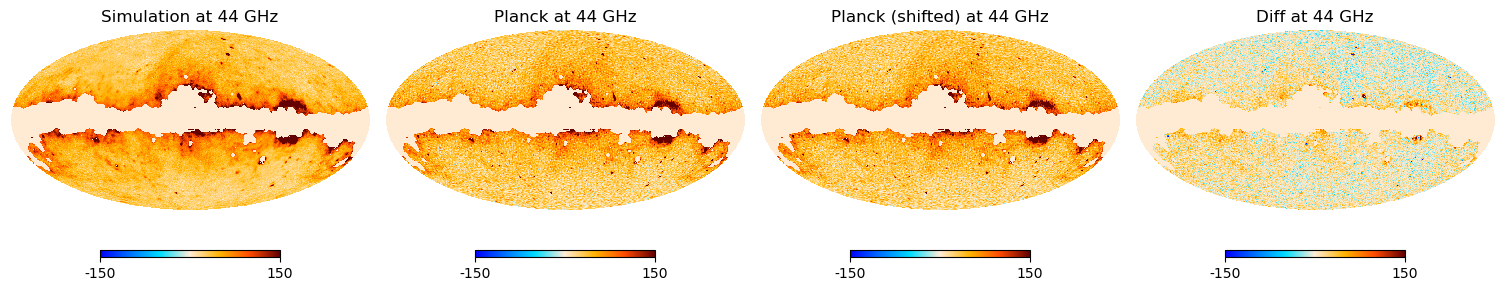

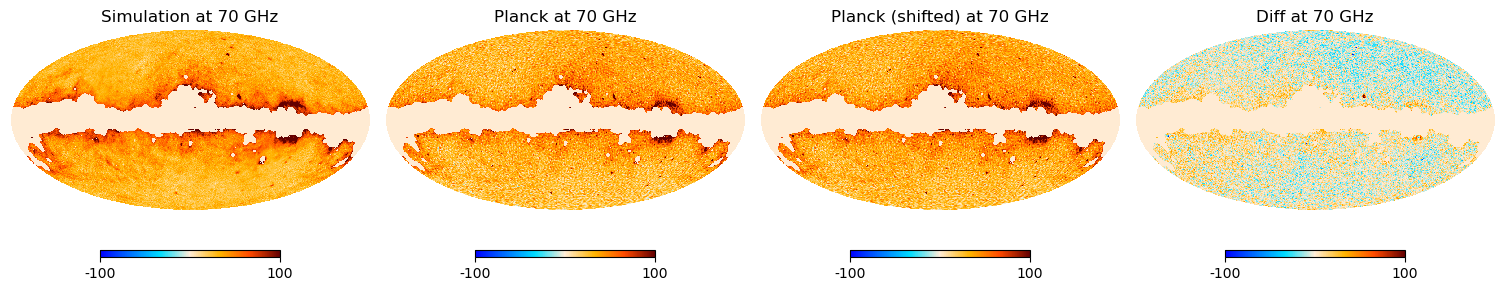

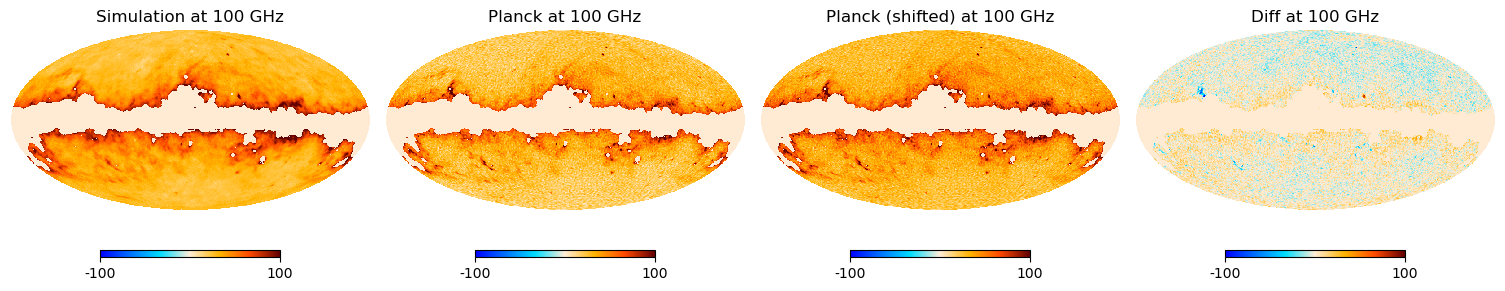

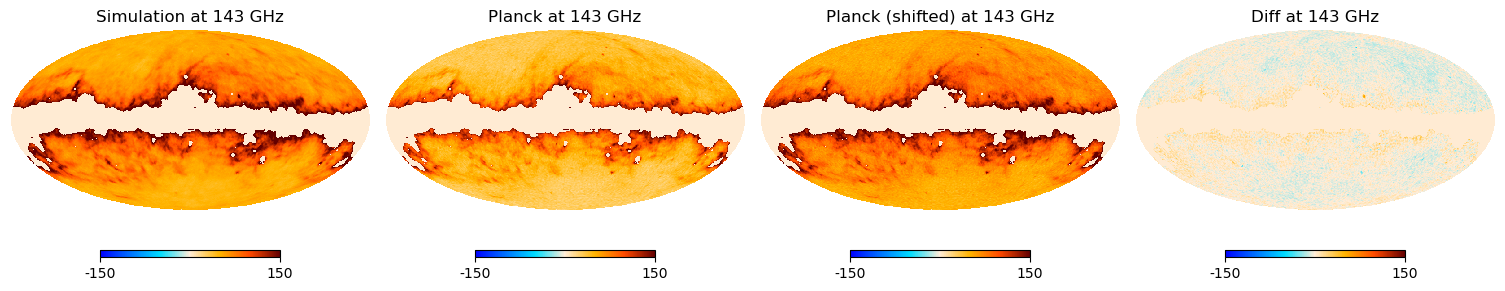

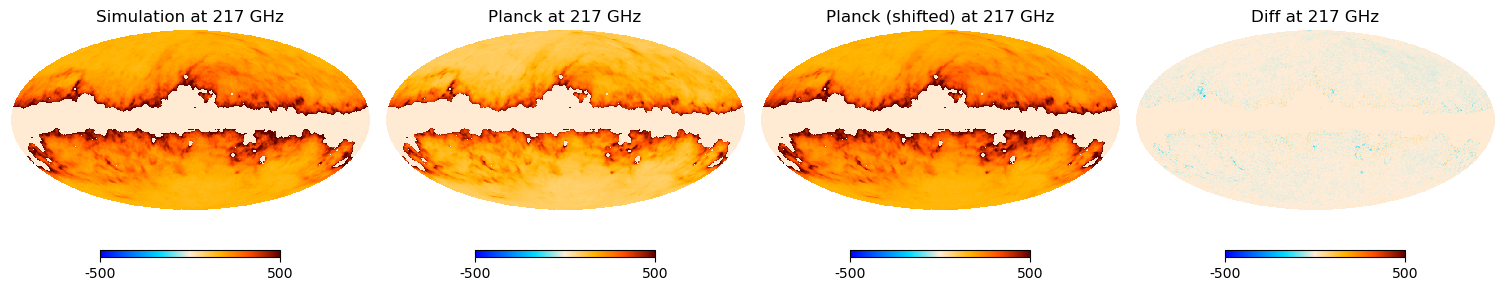

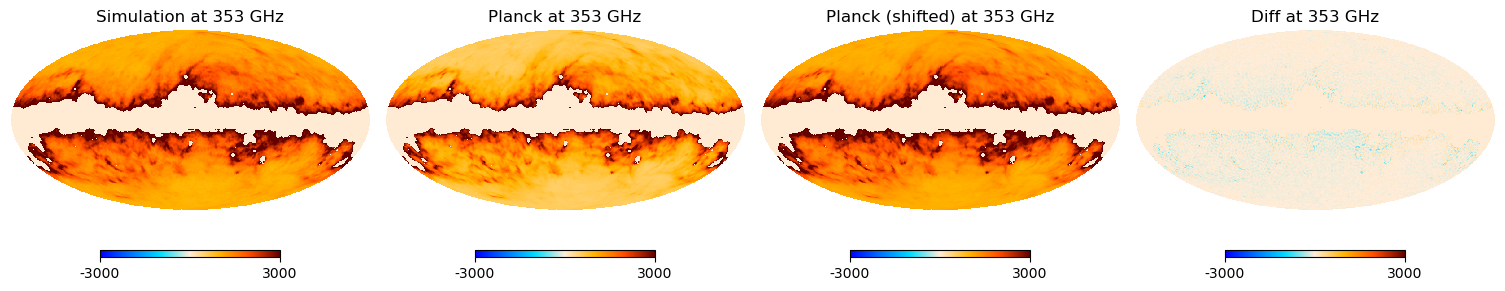

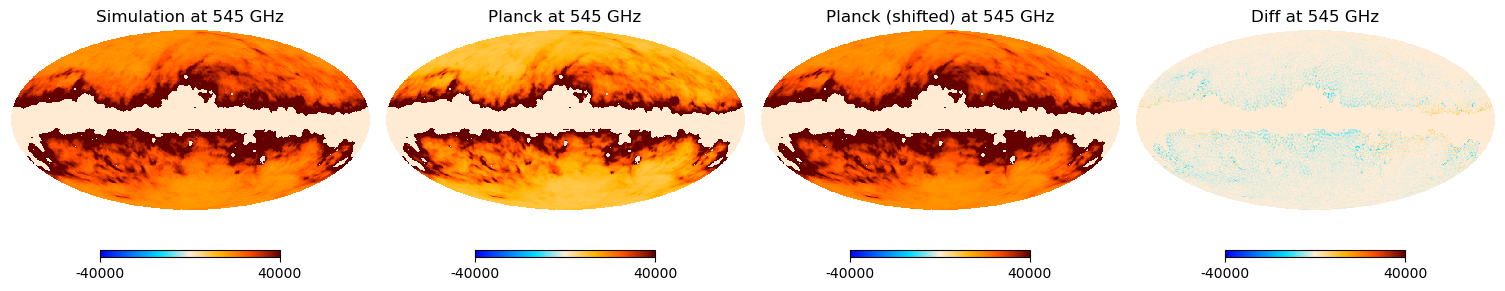

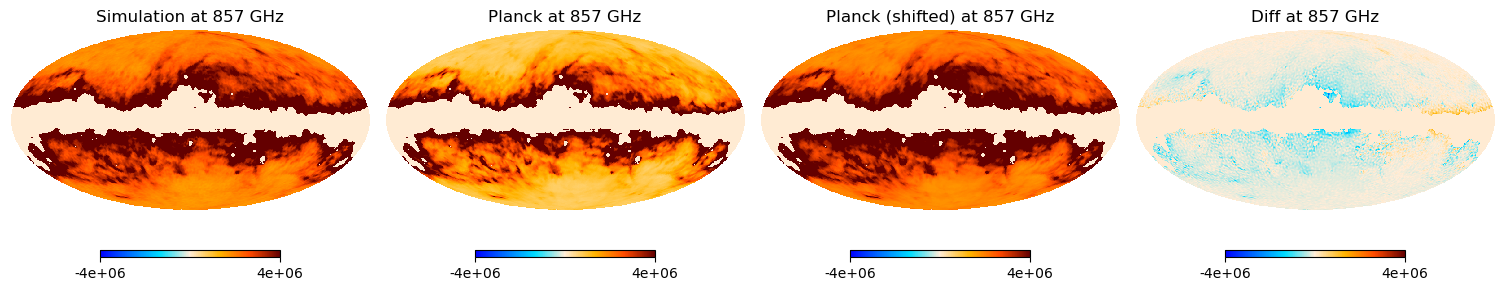

In [28]:
lockman_mask = create_lockman_mask()
pysm_all_component_dict_match, before_vec_match, after_vec_match, offset_list = plot_lockman_match(lockman_mask)

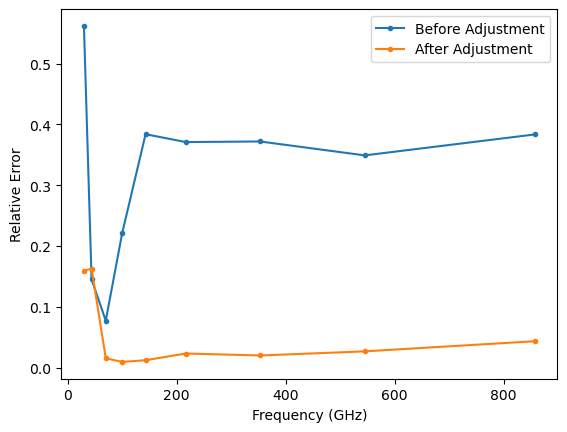

In [16]:
plt.plot(freqs,abs(np.array(before_vec_match)),'.-',label='Before Adjustment')
plt.plot(freqs,abs(np.array(after_vec_match)),'.-',label = 'After Adjustment')
plt.ylabel('Relative Error')
plt.xlabel('Frequency (GHz)')
plt.legend()

Fractional RMS difference: 1.56


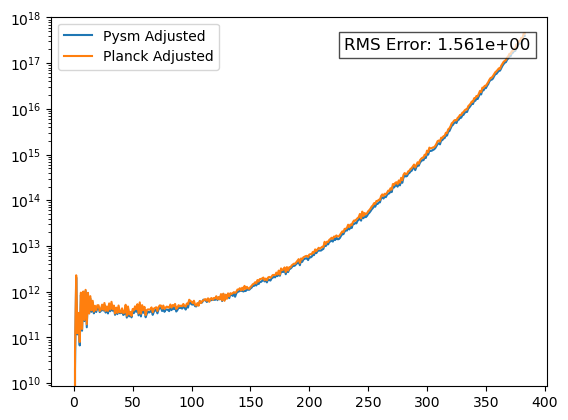

In [17]:
freq = 857
lmax = 3*Nside-1
pysm_ps = get_power(pysm_all_component_dict_match[freq],pysm_all_component_dict_match[freq],mask,lmax=lmax)
planck_ps = get_power(planckdict[freq],planckdict[freq],mask,lmax=lmax)
ells = np.arange(lmax+1)
beam = hp.sphtfunc.gauss_beam(np.radians(fwhm_128/60),lmax=lmax)
error = np.sqrt(np.mean((pysm_ps - planck_ps)**2)) / np.mean(planck_ps)
print(f"Fractional RMS difference: {error:.2f}")

# error2 = np.sum(pysm_ps - planck_ps) / np.sum(planck_ps)
# print("Relative difference:", error)

plt.plot(ells,ells*(ells+1)*pysm_ps/(2*np.pi*beam**2),label = 'Pysm Adjusted')
plt.plot(ells,ells*(ells+1)*planck_ps/(2*np.pi*beam**2),label = 'Planck Adjusted')
plt.text(0.6*lmax, max(ells*(ells+1)*pysm_ps/(2*np.pi*beam**2))*0.5, 
         f'RMS Error: {error:.3e}', fontsize=12, bbox=dict(facecolor='white', alpha=0.7))
plt.yscale('log')
plt.legend()

## Extra checks 

In [18]:
pysm_ps1 = get_power(pysm_all_component_dict_match[freq],pysm_all_component_dict_match[freq],mask,lmax=lmax)
planck_ps1 = get_power(planckdict[freq],planckdict[freq],mask,lmax=lmax)

pysm_ps2 = get_power(pysm_all_component_dict[freq],pysm_all_component_dict[freq],mask,lmax=lmax)
planck_ps2 = get_power(planckdict[freq],planckdict[freq],mask,lmax=lmax)

In [19]:
pysm_ps1-pysm_ps2

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

In [20]:
offsets = []
for freq in freqs:
    planck = planckdict[freq]
    sim = noisedict[freq].copy()
    for fg in fgs:
        sim += pysmdict[freq][fg]
    planck_avg = np.sum(planck * lockman_mask) / np.sum(lockman_mask)
    sim_avg    = np.sum(sim * lockman_mask) / np.sum(lockman_mask)
    offsets.append(sim_avg - planck_avg)
print("Offsets (sim - planck) per freq:", dict(zip(freqs, offsets)))

Offsets (sim - planck) per freq: {30: 28.968790131985234, 44: -0.6671321169482134, 70: 2.175815761175322, 100: 6.77061748028229, 143: 22.46113873506542, 217: 72.5193424056984, 353: 486.66271556126355, 545: 8551.04237581324, 857: 1046473.881417983}


In [29]:
offset_list

[28.968790131985234,
 -0.6671321169482134,
 2.175815761175322,
 6.77061748028229,
 22.46113873506542,
 72.5193424056984,
 486.66271556126355,
 8551.04237581324,
 1046473.881417983]

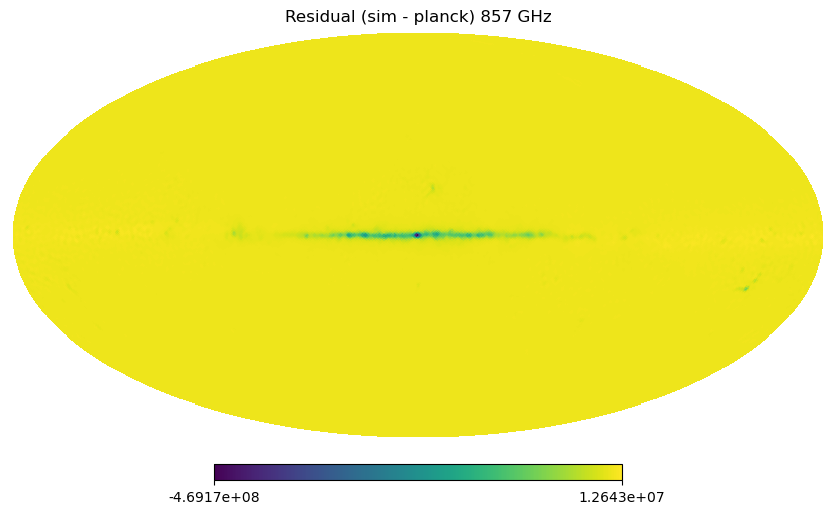

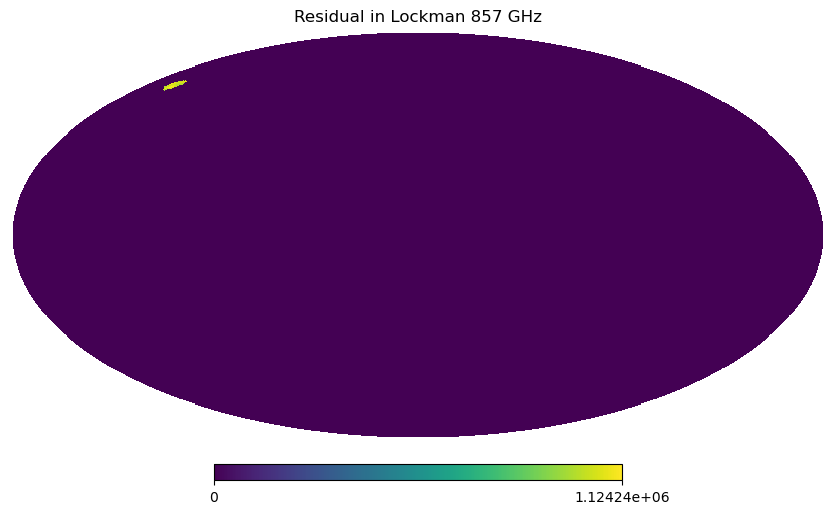

In [24]:
res = sim - planck
hp.mollview(res, title=f"Residual (sim - planck) {freq} GHz") 
#view of Lockman:
hp.mollview(res * lockman_mask, title=f"Residual in Lockman {freq} GHz")

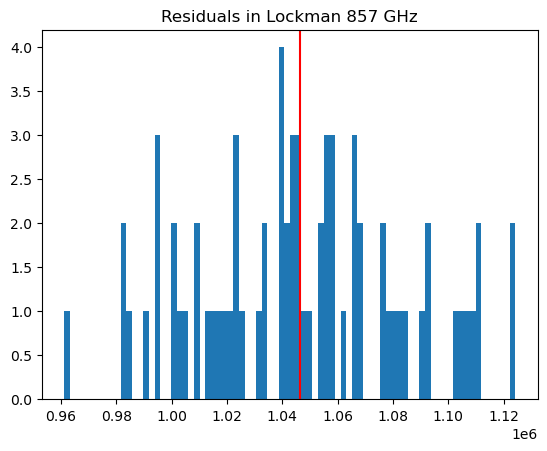

In [25]:
pix = np.where(lockman_mask==1)[0]
vals = (sim - planck)[pix]
plt.hist(vals, bins=80)
plt.title(f"Residuals in Lockman {freq} GHz")
plt.axvline(np.mean(vals), color='r')

Text(0, 0.5, 'offset (units)')

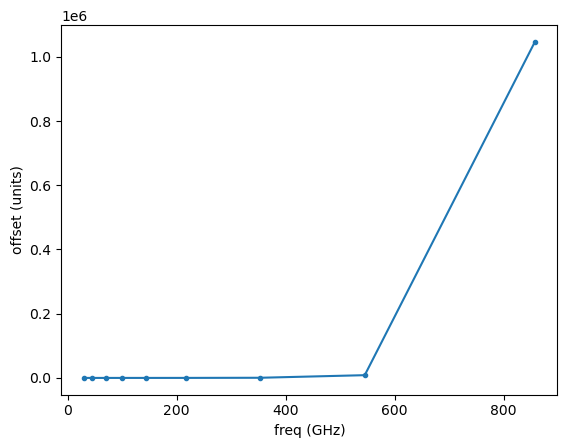

In [23]:
plt.plot(freqs, offsets, '.-'); plt.xlabel('freq (GHz)'); plt.ylabel('offset (units)')
